<a href="https://colab.research.google.com/github/aleksandra-st/Datacenters-Distrubition-Network/blob/main/checker_datacenter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
!pip install folium geopy
file_path = '/content/datacenters locations - summary (1).csv'
df = pd.read_csv(file_path)

print("Columns in the CSV file:")
print(df.columns.tolist())

Columns in the CSV file:
['name', 'type', 'address', 'company']


In [ ]:
display(df.head())

,name,type,address,company
0,Miyun Resevoir,Water_source,"Miyun District, Beijing, China",Amazon
1,Susquehanna Steam Electric Station,nuclear_power_plant,"634 Confers Ln, Berwick, PA 18603, USA",Amazon
2,InterXion,data_center,"Sagereistrasse 35, Zurich, Switzerland",Amazon
3,NextDC C1,data_center,"19 Battye St, Canberra, Australia",Amazon
4,Johnson Camp Mine,copper_main,"11050 N West Rd, Dragoon, AZ 85609, USA",Amazon


In [ ]:
import re
import matplotlib.pyplot as plt

# Function to extract country from address
# This is a heuristic and might need adjustment based on address format
def extract_country(address):
    if isinstance(address, str):
        parts = [part.strip() for part in address.split(',')]
        # Try to find a common country name or assume the last part is the country
        # This can be improved with a more robust geocoding library if needed
        countries = [
            "USA", "United States", "Germany", "France", "UK", "United Kingdom", "Japan", "China",
            "Canada", "Australia", "India", "Brazil", "Russia", "South Africa", "Netherlands",
            "Ireland", "Singapore", "Hong Kong", "Sweden", "Finland", "Denmark", "Norway",
            "Switzerland", "Austria", "Spain", "Italy", "Belgium", "Luxembourg", "UAE",
            "Saudi Arabia", "Mexico", "Argentina", "New Zealand", "South Korea", "Malaysia",
            "Indonesia", "Thailand", "Vietnam", "Philippines", "Egypt", "Israel", "Turkey"
        ]
        for part in reversed(parts):
            for country in countries:
                if country.lower() in part.lower():
                    return country
        # If no common country found, return the last part as a fallback
        if parts: #ensure parts is not empty
            return parts[-1]
    return 'Unknown'

# Apply the function to create a new 'country' column
df['country'] = df['address'].apply(extract_country)

print("DataFrame with 'country' column added:")
display(df.head())

DataFrame with 'country' column added:


,name,type,address,company,country
0,Miyun Resevoir,Water_source,"Miyun District, Beijing, China",Amazon,China
1,Susquehanna Steam Electric Station,nuclear_power_plant,"634 Confers Ln, Berwick, PA 18603, USA",Amazon,USA
2,InterXion,data_center,"Sagereistrasse 35, Zurich, Switzerland",Amazon,Switzerland
3,NextDC C1,data_center,"19 Battye St, Canberra, Australia",Amazon,Australia
4,Johnson Camp Mine,copper_main,"11050 N West Rd, Dragoon, AZ 85609, USA",Amazon,USA


In [ ]:
def analyze_country_data(country_name):
    country_df = df[df['country'].str.contains(country_name, case=False, na=False)]

    if country_df.empty:
        print(f"No data found for country: {country_name}")
        return

    print(f"\nLocations in {country_name}:")
    for index, row in country_df.iterrows():
        print(f"- {row['name']} ({row['type']}) at {row['address']}")

    # Standardize the 'type' column before calculating proportions
    # This handles potential issues like leading/trailing spaces or inconsistent casing
    country_df['type_cleaned'] = country_df['type'].str.strip().str.lower()
    type_proportions = country_df['type_cleaned'].value_counts(normalize=True) * 100

    print(f"\nProportion of 'type' categories in {country_name}:")
    print(type_proportions)

    # Create a pie chart with distinct colors for each type
    plt.figure(figsize=(8, 8))
    # Get a colormap and generate colors based on the number of unique types
    colors = plt.cm.tab20.colors[:len(type_proportions)]
    plt.pie(type_proportions, labels=type_proportions.index, autopct='%1.1f%%', startangle=90, colors=colors)
    plt.title(f"Proportion of Asset Types in {country_name}")
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

print("To use, call `analyze_country_data('your_country_name')`. For example, `analyze_country_data('USA')`")

To use, call `analyze_country_data('your_country_name')`. For example, `analyze_country_data('USA')`


Please enter a country name to analyze (e.g., USA, Australia, China): France

Locations in France:
- Equinix PA3 (data_center) at Rue Ambroise Croizat, 114, Paris, France
- Equinix PA6 (data_center) at 10 Rue Waldeck Rochet, Paris, France
- Telehouse Voltaire (data_center) at 137 Boulevard Voltaire, Paris, France
- Digital Realty MRS (data_center) at Port of Marseille, Gate 4, Marseille, France
- Google Châteauroux (data_center) at within Parc d'activités d'Ozans, Châteauroux, France

Proportion of 'type' categories in France:
type_cleaned
data_center    100.0
Name: proportion, dtype: float64


/tmp/ipykernel_805/3083484902.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  country_df['type_cleaned'] = country_df['type'].str.strip().str.lower()


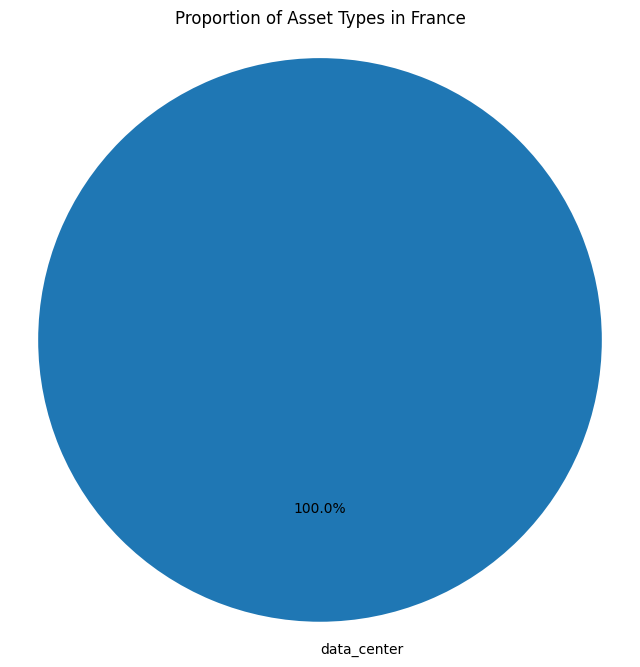

In [ ]:
country_input = input("Please enter a country name to analyze (e.g., USA, Australia, China): ")
analyze_country_data(country_input)

In [48]:
import os

# --- Step 1: List all .ipynb files to help identify your notebook (This might not work in all Colab setups) ---
print("Available .ipynb files in the current directory:")
ipynb_files = [f for f in os.listdir('.') if f.endswith('.ipynb')]
if ipynb_files:
    for f_name in ipynb_files:
        print(f"- {f_name}")
else:
    print("No .ipynb files found in current directory. Please get the notebook name from your Colab tab title or file browser.")

# --- Step 2: Set your notebook's actual filename here ---
# IMPORTANT: Replace 'your_notebook_name.ipynb' with the actual name of this notebook.
# You can find the name in the browser tab title or the Colab file browser.
notebook_name = "checker_datacenter.ipynb" # <--- **UPDATE THIS LINE** with your notebook's correct filename.
# For example: notebook_name = "Untitled.ipynb"

# --- Step 3: Proceed with conversion (after updating notebook_name) ---
# Install nbconvert if not already installed (usually pre-installed in Colab)
!pip install nbconvert

# Convert the notebook to HTML, excluding the input code cells
# The output HTML file will be in the same directory as the notebook.
html_output_file = notebook_name.replace('.ipynb', '.html')
!jupyter nbconvert --to html "{notebook_name}" --output "{html_output_file}" --no-input

print(f"\nNotebook converted to HTML (code hidden): {html_output_file}")
print(f"You can download this file from the file browser on the left sidebar.")

# If the notebook name is still not correct, you might get an error.
# In that case, please ensure you've saved your notebook and updated 'notebook_name' accurately.


Available .ipynb files in the current directory:
No .ipynb files found in current directory. Please get the notebook name from your Colab tab title or file browser.
[NbConvertApp] WARNING | pattern 'checker_datacenter.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
   

In [50]:
import os

print("Files in the current directory:")
!ls -F

Files in the current directory:
'datacenters locations - summary (1).csv'   sample_data/
